### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 21/21 [00:20<00:00,  1.01it/s]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882829,2026-03-15 13:59:35,71565.000000,71580.000000,71565.000000,71577.703125,3.286,0.213,0.197,0.016,0.849765,...,0.004,1.064,2.575,0.009,0.002,0.004,0.002,0.004,0.004,4.445
882830,2026-03-15 13:59:40,71574.898438,71578.000000,71574.898438,71578.000000,0.110,0.039,0.039,0.000,1.000000,...,0.529,0.013,0.023,0.002,0.003,0.004,1.070,2.575,0.009,0.004
882831,2026-03-15 13:59:45,71593.898438,71595.296875,71578.000000,71587.203125,5.328,0.831,0.424,0.407,0.020457,...,0.004,0.450,0.013,0.006,1.957,0.056,0.811,2.521,0.005,0.006
882832,2026-03-15 13:59:50,71582.398438,71591.203125,71580.000000,71585.101562,0.619,0.033,0.000,0.033,-1.000000,...,0.487,0.005,0.069,0.006,0.002,0.014,0.069,0.006,0.008,0.003


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 882833/882833 [00:07<00:00, 119347.22it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,0.000159,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.143416,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,0.000214,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.136184,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,0.000275,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.136184,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,0.000443,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.132611,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,0.000956,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.139892,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882829,4.779948,0.052937,8.054022,9.305540,0.000026,4.779941,0.713813,4.123703,1.897578,46.396939,...,0.273166,4.308954,5.428093,0.802900,0.766069,71565.000000,71580.000000,71577.703125,-0.000018,0.000043
882830,4.869922,0.229000,7.888940,9.024645,0.000027,4.869915,0.601953,1.338451,0.604044,21.882786,...,0.252045,1.831606,2.528872,0.502905,0.496804,71574.898438,71578.000000,71578.000000,0.000121,0.000242
882831,4.463281,0.847000,8.202538,9.445178,0.000015,4.463275,0.025000,-1.374123,-1.293351,-16.946194,...,0.244533,1.039520,-2.885227,-0.693534,-0.899081,71578.000000,71595.296875,71587.203125,-0.000022,0.000156
882832,4.523307,1.775000,8.302557,9.623731,0.000016,4.523301,0.147656,-0.115819,-0.095717,-3.237604,...,0.236576,1.561454,-0.668324,-0.244759,-0.248329,71580.000000,71591.203125,71585.101562,-0.000009,0.000068


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00018
[50]	validation_0-rmse:0.00018
[100]	validation_0-rmse:0.00017
[150]	validation_0-rmse:0.00017
[200]	validation_0-rmse:0.00017
[250]	validation_0-rmse:0.00017
[300]	validation_0-rmse:0.00017
[350]	validation_0-rmse:0.00017
[400]	validation_0-rmse:0.00017
[450]	validation_0-rmse:0.00017
[500]	validation_0-rmse:0.00017
[550]	validation_0-rmse:0.00017
[600]	validation_0-rmse:0.00017
[650]	validation_0-rmse:0.00017
[700]	validation_0-rmse:0.00017
[750]	validation_0-rmse:0.00017
[800]	validation_0-rmse:0.00017
[850]	validation_0-rmse:0.00017
[900]	validation_0-rmse:0.00017
[950]	validation_0-rmse:0.00017
[1000]	validation_0-rmse:0.00017
[1050]	validation_0-rmse:0.00017
[1100]	validation_0-rmse:0.00017
[1150]	validation_0-rmse:0.00017
[1200]	validation_0-rmse:0.00017
[1250]	validation_0-rmse:0.00017
[1300]	validation_0-rmse:0.00017
[1350]	validation_0-rmse:0.00017
[1400]	validation_0-rmse:0.00017
[1450]	validation_0-rmse:0.00017
[1500]	validat

MAE                      : 0.000103
RMSE                     : 0.000165
R²                       : 0.201377
MAE / mean|Δ|            : 0.864814
RMSE / RMSE_base         : 0.893626
mean|Δ| (target)         : 0.000119

------------------------------------------------------------
Directional Accuracy     : 0.615334
Target Pos Ratio         : 0.476402
Profit Factor            : 2.413732
Avg Gain (correct)       : -0.000004
Avg Loss (incorrect)     : 0.000003

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6132, 0.6175)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
   (0.000105, 0.001]    0.000198         0.895163    -0.000007      17656
(5.97e-05, 0.000105]    0.000078         0.761667    -0.000002      17656
(4.22e-05, 5.97e-05]    0.000050         0.705596    -0.000004      17656


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


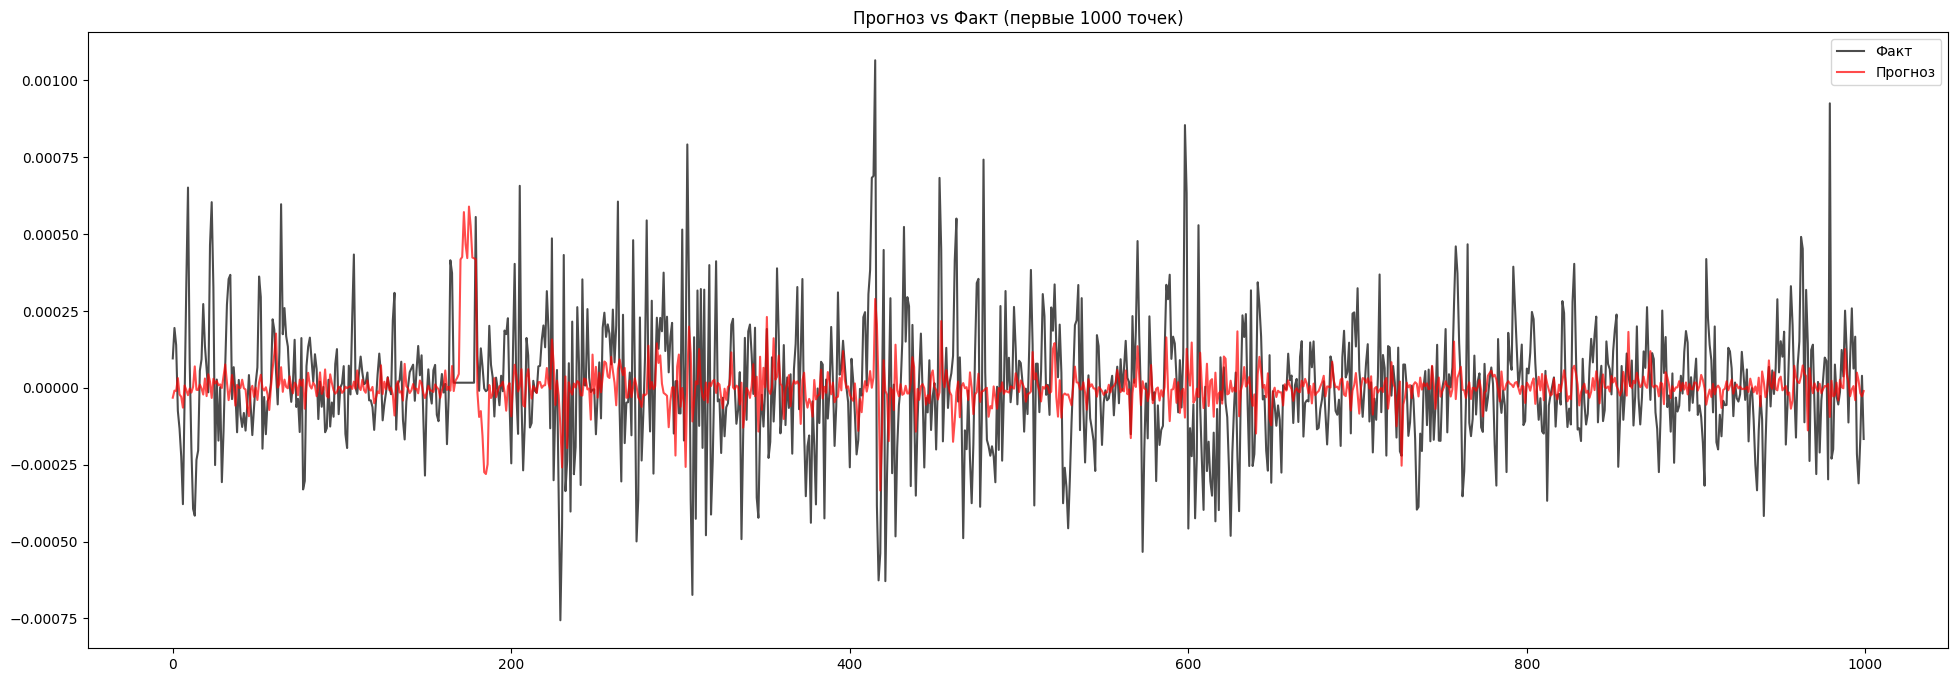

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00021
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00016
[200]	validation_0-rmse:0.00016
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[750]	validation_0-rmse:0.00015
[788]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000102
RMSE                     : 0.000154
R²                       : 0.407723
MAE / mean|Δ|            : 0.578869
RMSE / RMSE_base         : 0.576706
mean|Δ| (target)         : 0.000177

------------------------------------------------------------
Directional Accuracy     : 0.892791
Target Pos Ratio         : 0.892791
Profit Factor            : 31191239791.865219
Avg Gain (correct)       : 0.000198
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8914, 0.8941)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000349, 0.00213]    0.000477         0.999830     0.000471      17656
(0.000256, 0.000349]    0.000296         0.997508     0.000295      17656
(0.000206, 0.000256]    0.000229         0.988559     0.000227    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


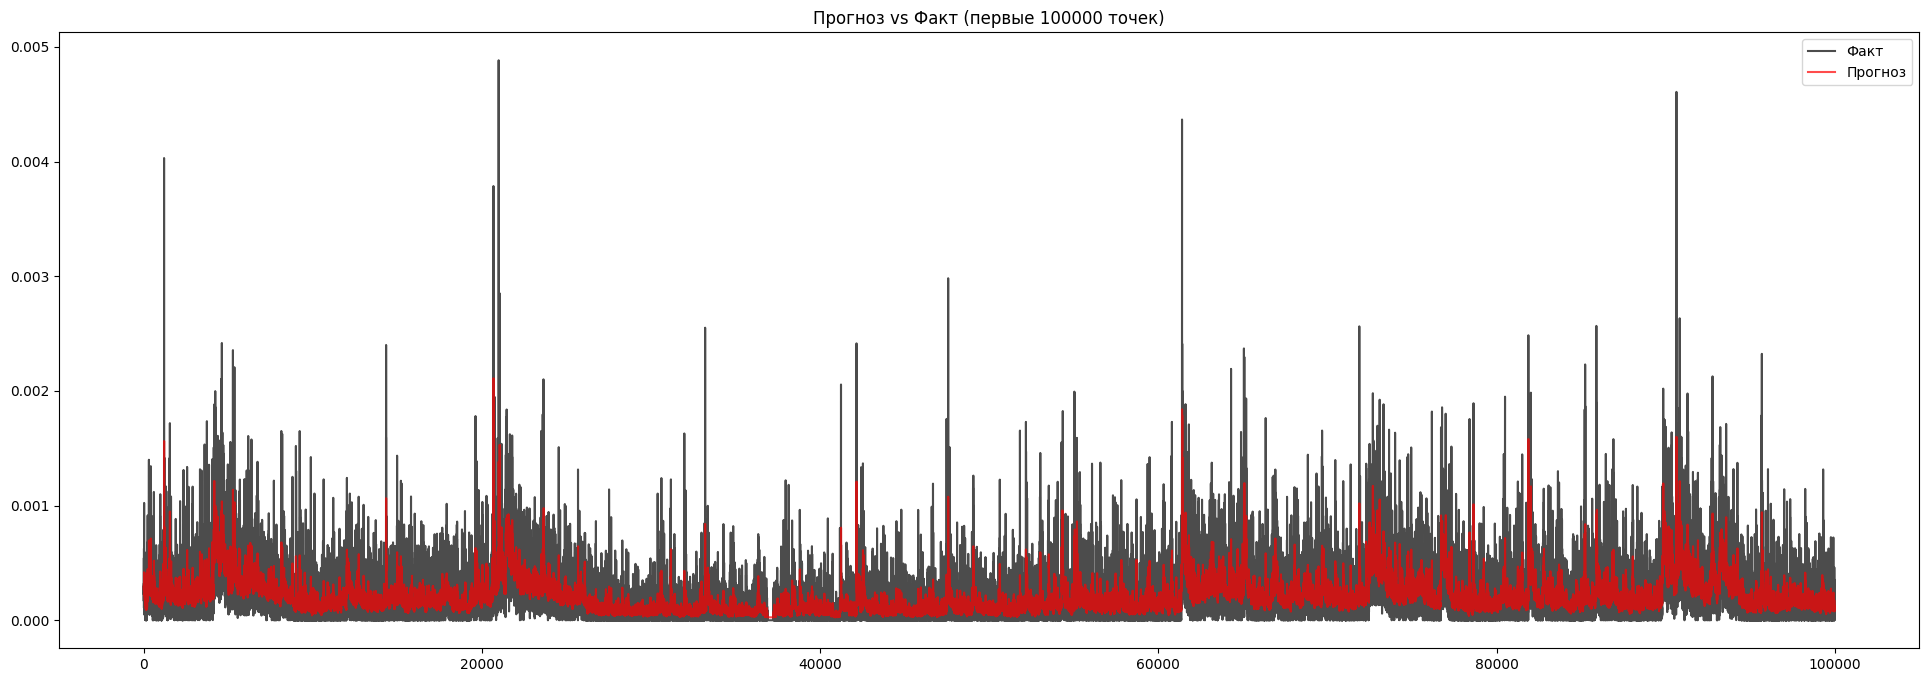

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)